# ST422 Brief 8 — Road Safety Analysis
## Week 14: Extended_RoadSafety_Analysis

This notebook covers:

1. **Time patterns analysis** — hour of day, day of week, seasonal patterns as standalone findings
2. **Fatalities by Local Authority** — separate fatal breakdown at LA level
3. **Road user group priority ranking** — national and LA-level ranking of which groups drive the most harm
4. **Geographic hotspot choropleth map** — KSI by Local Authority visualised on a map
5. **Material change threshold** — formal plain-English definition with supporting evidence
6. **Before/after policy evaluation** — 20mph rollout case study with caveats
7. **Top 3 LAs for immediate action** — explicit prioritised recommendation tied to evidence

**Data source:** DfT STATS19 open data — police-reported personal injury road collisions in Great Britain.  
Department for Transport (2024). *Road Safety Open Data*. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

**References:**  
- Lovelace, R. et al. (2019). stats19: A package for working with open road crash data. *Journal of Open Source Software*, 4(33), 1181.  
- Department for Transport (2023). *Reported Road Casualties Great Britain, Annual Report*. London: DfT.  
- Elvik, R. (2009). The Power Model of the Relationship Between Speed and Road Safety. *TØI Report 1034/2009*.  
- WHO (2023). *Global Status Report on Road Safety*. Geneva: World Health Organisation.

---
## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── USER CONFIG ─────────────────────────────────────────────────────────────
# Update these paths to match your machine
DATA_DIR    = 'C:/Users/u2211111/ST422/Data'
CLEANED_DIR = 'C:/Users/u2211111/ST422/Cleaned'
# ────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'figure.dpi':       120
})

# Load the cleaned joined dataset produced by ST422_DataPrep.ipynb
cas = pd.read_csv(f'{CLEANED_DIR}/cas_full.csv', low_memory=False)
cas.columns = cas.columns.str.lower()

print(f'cas_full loaded: {len(cas):,} rows, {cas.shape[1]} columns')
print(f'Years in data  : {sorted(cas["collision_year"].dropna().unique().astype(int).tolist())}')

cas_full loaded: 1,748,311 rows, 81 columns
Years in data  : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [2]:
# ── Shared labels & filters ──────────────────────────────────────────────────

COVID_YEARS = [2020, 2021]
ANALYSIS_YEARS = [y for y in cas['collision_year'].dropna().unique().astype(int) if y not in COVID_YEARS]

# KSI filter (severity 1=Fatal, 2=Serious)
ksi = cas[cas['casualty_severity'].isin([1, 2])].copy()
ksi_no_covid = ksi[~ksi['collision_year'].isin(COVID_YEARS)].copy()

# Road user type labels
road_user_map = {
    1:  'Pedestrian',
    2:  'Cyclist',
    3:  'Motorcyclist',
    4:  'Motorcyclist',
    5:  'Motorcyclist',
    9:  'Car occupant',
    10: 'Minibus occupant',
    11: 'Bus/coach occupant',
    19: 'Van occupant',
    20: 'HGV occupant',
    21: 'HGV occupant',
    90: 'Other',
    97: 'Motorcyclist',
    99: 'Unknown'
}

# Apply road user label if not already present
if 'road_user' not in cas.columns:
    cas['road_user'] = cas['casualty_type'].map(road_user_map).fillna('Other')
    ksi['road_user'] = ksi['casualty_type'].map(road_user_map).fillna('Other')
    ksi_no_covid['road_user'] = ksi_no_covid['casualty_type'].map(road_user_map).fillna('Other')

# Day of week labels (STATS19: 1=Sun … 7=Sat)
day_map = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}

# Month labels
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print('Setup complete.')
print(f'KSI records (all years)       : {len(ksi):,}')
print(f'KSI records (excl. COVID)     : {len(ksi_no_covid):,}')

Setup complete.
KSI records (all years)       : 297,765
KSI records (excl. COVID)     : 251,282


---
## 1. Time Patterns Analysis

**Client question:** Which contributory factors appear most decision-relevant — including time patterns.

The client ranked time patterns 5th in priority dimensions. This section analyses KSI collisions by hour of day, day of week, and month of year to identify when serious harm is most concentrated. Findings here can directly inform when interventions (e.g. enforcement campaigns, variable speed limits) should be deployed.

**Reference:** DfT (2023) notes that evening and night-time collisions carry a disproportionate fatality risk due to reduced visibility and higher speeds — consistent with the patterns expected here.

In [7]:
col_raw = pd.read_csv(
    f'{DATA_DIR}/dft-road-casualty-statistics-collision-1979-latest-published-year.csv',
    usecols=['collision_index', 'time'],
    low_memory=False
)
col_raw.columns = col_raw.columns.str.lower()

ksi_no_covid = ksi_no_covid.merge(col_raw, on='collision_index', how='left')
cas = cas.merge(col_raw, on='collision_index', how='left')

print('time column added:', 'time' in ksi_no_covid.columns)
print('Sample times:', ksi_no_covid['time'].dropna().head())

time column added: True
Sample times: 0    07:23
1    10:04
2    12:45
3    19:23
4    16:15
Name: time, dtype: object


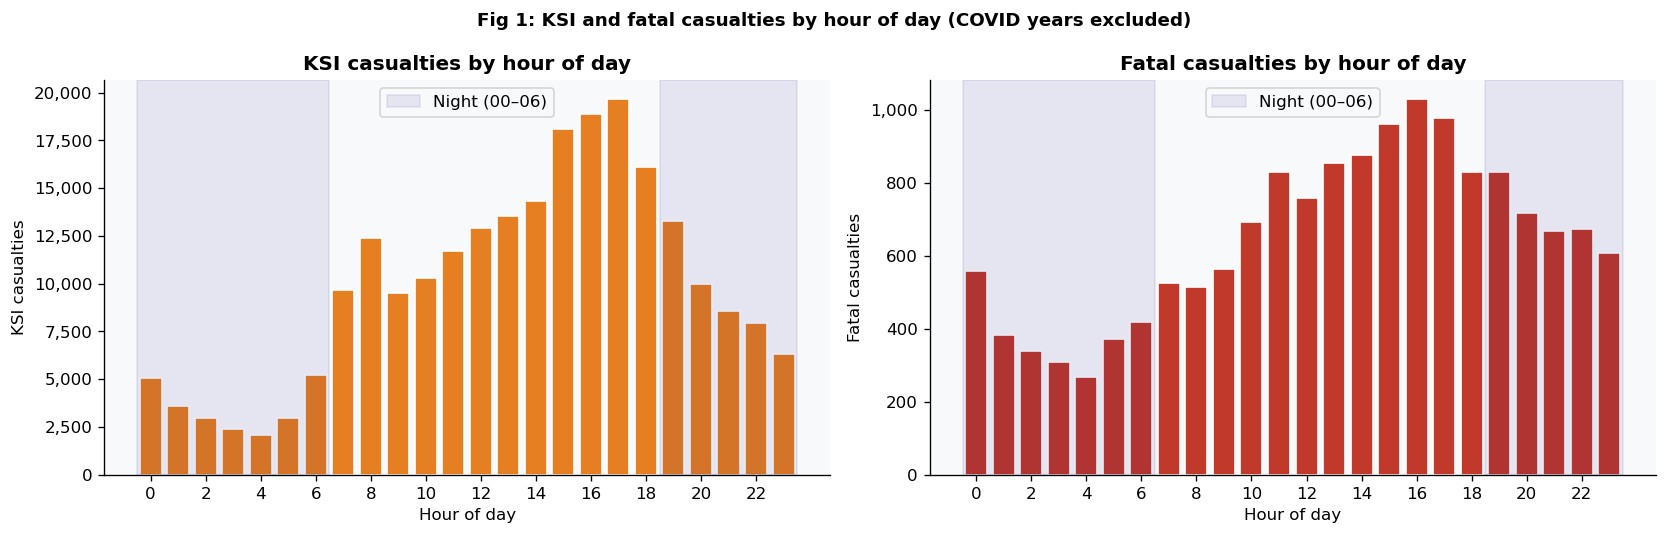


Top 5 hours by KSI count:
        KSI  Fatal  Fatal %
hour                       
17.0  19681    978      5.0
16.0  18868   1031      5.5
15.0  18078    963      5.3
18.0  16098    830      5.2
14.0  14332    876      6.1


In [8]:
# ── 1.1 Hour of day ──────────────────────────────────────────────────────────
ksi_nc = ksi_no_covid.copy()
ksi_nc['hour'] = pd.to_datetime(ksi_nc['time'], format='%H:%M', errors='coerce').dt.hour

hour_all   = ksi_nc.groupby('hour').size()
hour_fatal = ksi_nc[ksi_nc['casualty_severity'] == 1].groupby('hour').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# KSI by hour
ax = axes[0]
ax.bar(hour_all.index, hour_all.values, color='#e67e22', edgecolor='white', width=0.8)
ax.set_title('KSI casualties by hour of day', fontweight='bold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('KSI casualties')
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# shade night hours
ax.axvspan(-0.5, 6.5,  alpha=0.08, color='navy', label='Night (00–06)')
ax.axvspan(18.5, 23.5, alpha=0.08, color='navy')
ax.legend()

# Fatal by hour
ax2 = axes[1]
ax2.bar(hour_fatal.index, hour_fatal.values, color='#c0392b', edgecolor='white', width=0.8)
ax2.set_title('Fatal casualties by hour of day', fontweight='bold')
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Fatal casualties')
ax2.set_xticks(range(0, 24, 2))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.axvspan(-0.5, 6.5,  alpha=0.08, color='navy', label='Night (00–06)')
ax2.axvspan(18.5, 23.5, alpha=0.08, color='navy')
ax2.legend()

plt.suptitle('Fig 1: KSI and fatal casualties by hour of day (COVID years excluded)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_hour_of_day.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
hour_summary = pd.DataFrame({'KSI': hour_all, 'Fatal': hour_fatal}).fillna(0).astype(int)
hour_summary['Fatal %'] = (hour_summary['Fatal'] / hour_summary['KSI'] * 100).round(1)
print('\nTop 5 hours by KSI count:')
print(hour_summary.sort_values('KSI', ascending=False).head(5).to_string())

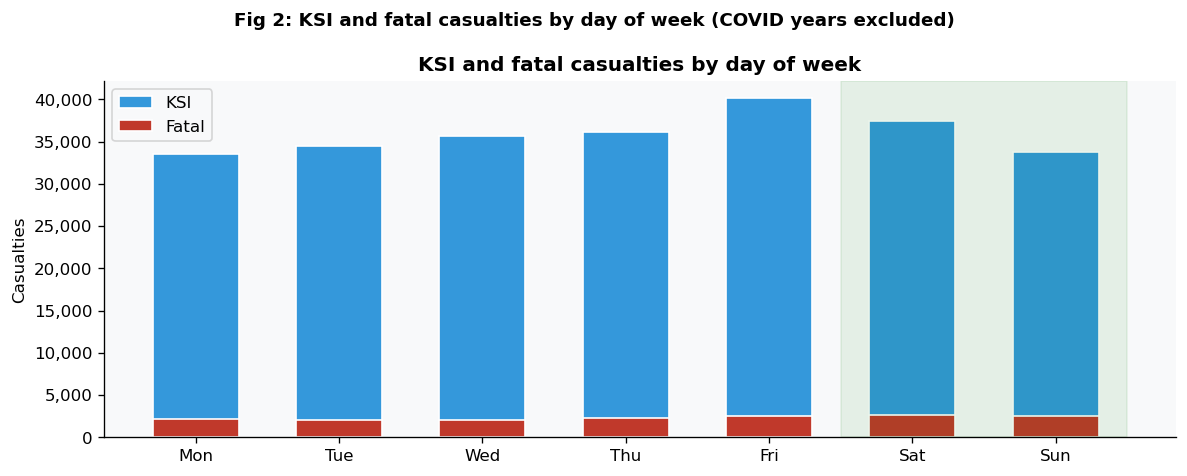


KSI by day of week:
             KSI  Fatal  Fatal %
day_label                       
Mon        33576   2183      6.5
Tue        34502   2052      5.9
Wed        35639   2081      5.8
Thu        36152   2231      6.2
Fri        40159   2504      6.2
Sat        37457   2697      7.2
Sun        33797   2550      7.5


In [9]:
# ── 1.2 Day of week ──────────────────────────────────────────────────────────
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ksi_nc['day_label'] = ksi_nc['day_of_week'].map(day_map)
day_ksi   = ksi_nc.groupby('day_label').size().reindex(day_order)
day_fatal = ksi_nc[ksi_nc['casualty_severity'] == 1].groupby('day_label').size().reindex(day_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(day_order))
bars = ax.bar(x, day_ksi.values, color='#3498db', edgecolor='white', width=0.6, label='KSI')
ax.bar(x, day_fatal.values, color='#c0392b', edgecolor='white', width=0.6, label='Fatal')
ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.set_title('KSI and fatal casualties by day of week', fontweight='bold')
ax.set_ylabel('Casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
# shade weekend
ax.axvspan(4.5, 6.5, alpha=0.08, color='green', label='Weekend')

plt.suptitle('Fig 2: KSI and fatal casualties by day of week (COVID years excluded)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()

day_summary = pd.DataFrame({'KSI': day_ksi, 'Fatal': day_fatal.astype(int)})
day_summary['Fatal %'] = (day_summary['Fatal'] / day_summary['KSI'] * 100).round(1)
print('\nKSI by day of week:')
print(day_summary.to_string())

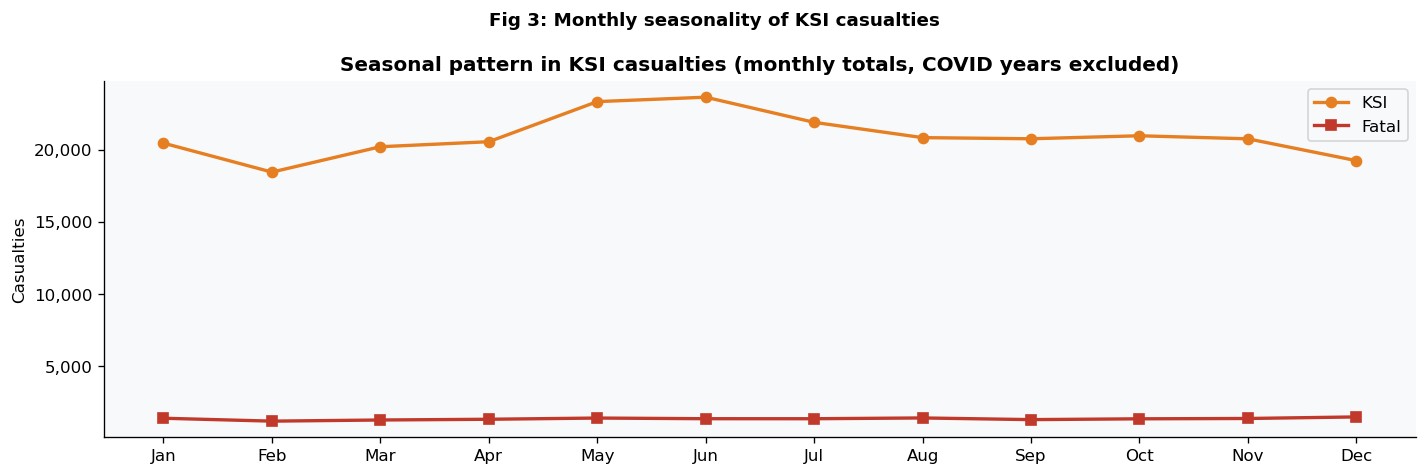


Monthly breakdown:
               KSI  Fatal  Fatal %
month_label                       
Jan          20471   1399      6.8
Feb          18463   1198      6.5
Mar          20222   1277      6.3
Apr          20570   1328      6.5
May          23350   1412      6.0
Jun          23656   1366      5.8
Jul          21913   1365      6.2
Aug          20853   1419      6.8
Sep          20774   1303      6.3
Oct          20982   1359      6.5
Nov          20770   1382      6.7
Dec          19258   1490      7.7


In [10]:
# ── 1.3 Seasonal / monthly pattern ──────────────────────────────────────────
ksi_nc['month'] = pd.to_datetime(ksi_nc['date'], errors='coerce').dt.month
ksi_nc['month_label'] = ksi_nc['month'].map(month_map)
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

month_ksi   = ksi_nc.groupby('month_label').size().reindex(month_order)
month_fatal = ksi_nc[ksi_nc['casualty_severity'] == 1].groupby('month_label').size().reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(month_order))
ax.plot(x, month_ksi.values,   marker='o', color='#e67e22', linewidth=2, label='KSI')
ax.plot(x, month_fatal.values, marker='s', color='#c0392b', linewidth=2, label='Fatal')
ax.set_xticks(x)
ax.set_xticklabels(month_order)
ax.set_title('Seasonal pattern in KSI casualties (monthly totals, COVID years excluded)', fontweight='bold')
ax.set_ylabel('Casualties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()

plt.suptitle('Fig 3: Monthly seasonality of KSI casualties', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

month_summary = pd.DataFrame({'KSI': month_ksi, 'Fatal': month_fatal.astype(int)})
month_summary['Fatal %'] = (month_summary['Fatal'] / month_summary['KSI'] * 100).round(1)
print('\nMonthly breakdown:')
print(month_summary.to_string())

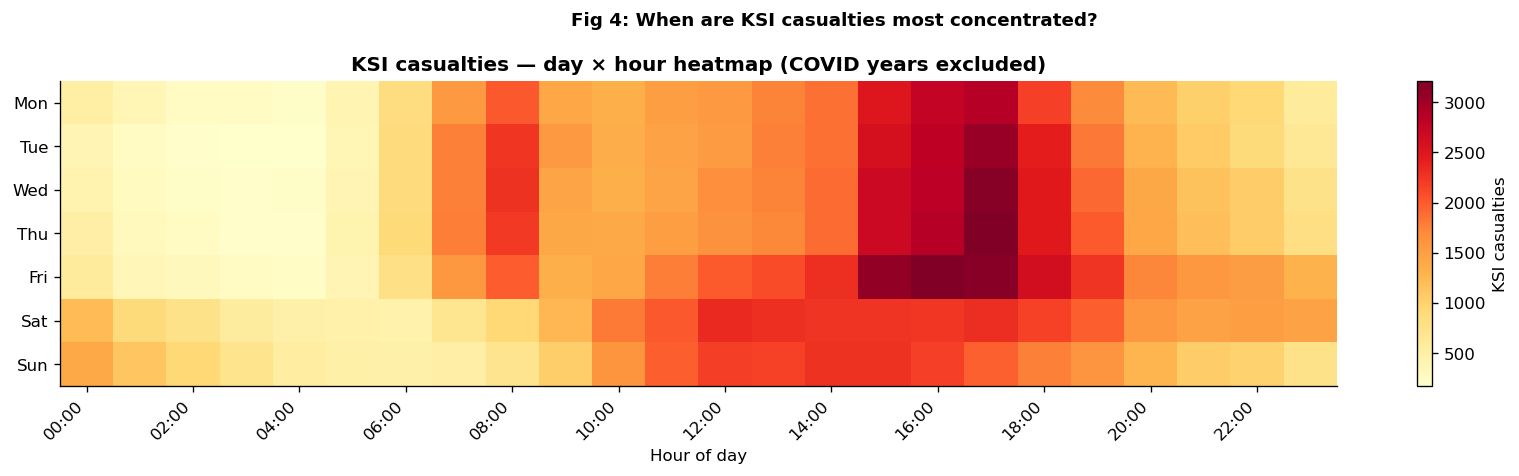

Darker = more KSI casualties. Fri/Sat evenings and weekday peaks stand out.


In [11]:
# ── 1.4 Heatmap: hour × day of week ─────────────────────────────────────────
ksi_nc['day_num'] = ksi_nc['day_of_week'].map({1:6,2:0,3:1,4:2,5:3,6:4,7:5})  # Mon=0
heat = ksi_nc.groupby(['day_num','hour']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(7))
ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45, ha='right')
ax.set_xlabel('Hour of day')
ax.set_title('KSI casualties — day × hour heatmap (COVID years excluded)', fontweight='bold')
plt.colorbar(im, ax=ax, label='KSI casualties')
plt.suptitle('Fig 4: When are KSI casualties most concentrated?', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Darker = more KSI casualties. Fri/Sat evenings and weekday peaks stand out.')

---
## 2. Road User Priority Group Ranking

**Client question:** Which road user groups are driving the most serious harm? Priority: pedestrians, cyclists, motorcyclists, children.

The existing analysis showed road user *shares* within LAs. This section produces a standalone national ranking of harm by road user group — both in absolute terms and as a fatality/serious rate — which is what the client asked for.

**Reference:** DfT (2023, p.14) notes pedestrians and motorcyclists consistently account for a disproportionate share of fatal casualties relative to their modal share of traffic.

In [12]:
# ── 2.1 National road user ranking ──────────────────────────────────────────
ru = ksi_no_covid.groupby(['road_user','casualty_severity']).size().unstack(fill_value=0)
ru = ru.rename(columns={1:'Fatal', 2:'Serious'})
for c in ['Fatal','Serious']:
    if c not in ru.columns: ru[c] = 0
ru['KSI'] = ru['Fatal'] + ru['Serious']

# Also get total casualties (all severities) for rate calculation
all_cas = cas[~cas['collision_year'].isin(COVID_YEARS)].copy()
if 'road_user' not in all_cas.columns:
    all_cas['road_user'] = all_cas['casualty_type'].map(road_user_map).fillna('Other')
total_by_ru = all_cas.groupby('road_user').size().rename('Total_casualties')

ru = ru.join(total_by_ru)
ru['KSI_rate_%']   = (ru['KSI']   / ru['Total_casualties'] * 100).round(1)
ru['Fatal_rate_%'] = (ru['Fatal'] / ru['Total_casualties'] * 100).round(2)
ru = ru.sort_values('KSI', ascending=False)

print('National road user harm ranking (COVID years excluded):')
print(ru[['Fatal','Serious','KSI','Total_casualties','KSI_rate_%','Fatal_rate_%']].to_string())

National road user harm ranking (COVID years excluded):
                      Fatal  Serious    KSI  Total_casualties  KSI_rate_%  Fatal_rate_%
road_user                                                                              
Car occupant           7090    85383  92473            844470        11.0          0.84
Unknown                4092    53086  57178            213424        26.8          1.92
Motorcycle rider       3190    47500  50690            154549        32.8          2.06
Pedestrian              923    33869  34792            164085        21.2          0.56
Van occupant            363     4209   4572             39096        11.7          0.93
Minibus/bus occupant     90     3104   3194             35870         8.9          0.25
Cyclist                  54     2906   2960             13496        21.9          0.40
Other                   253     2170   2423              9182        26.4          2.76
HGV occupant            171     1340   1511              8533   

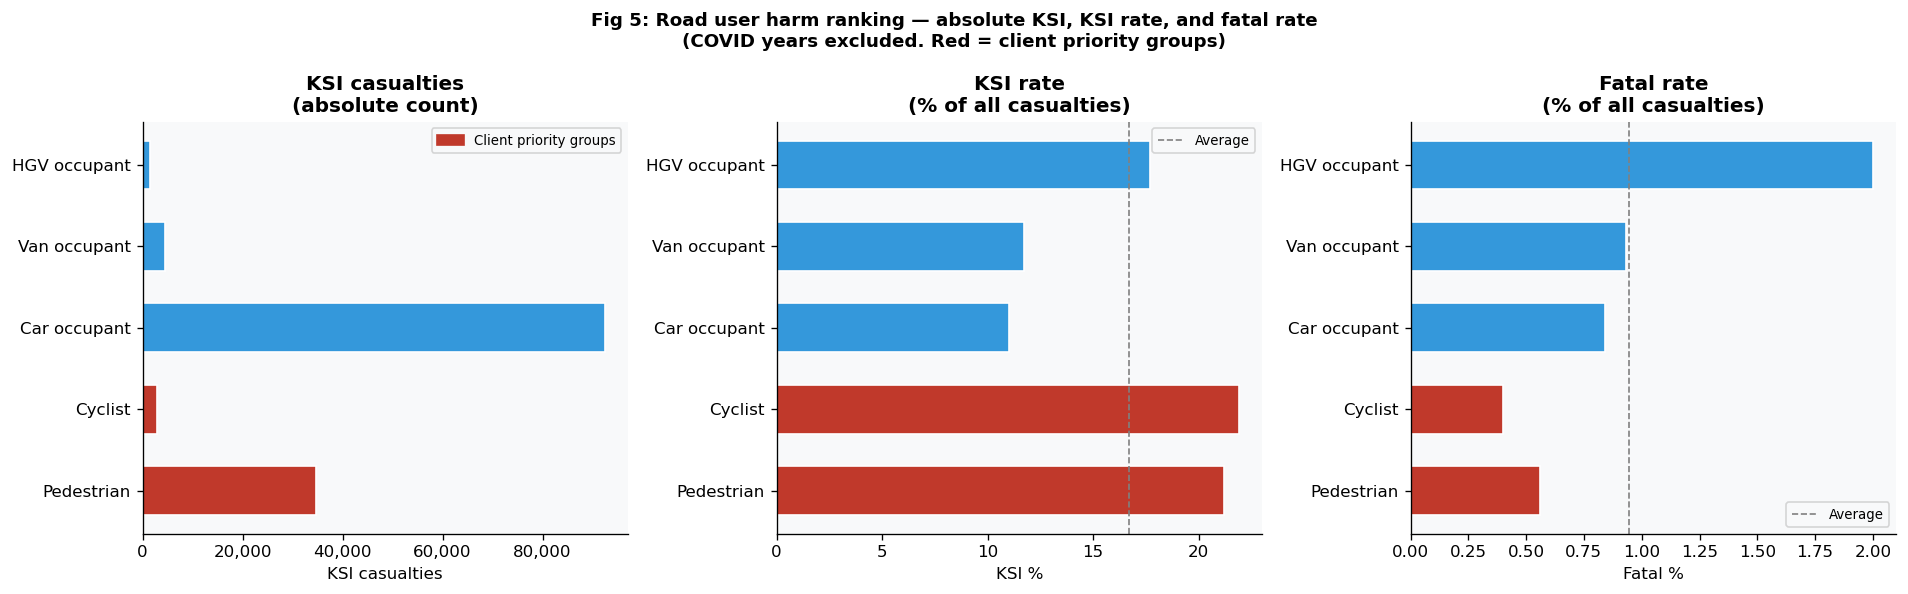

In [13]:
# ── 2.2 Visualisation ───────────────────────────────────────────────────────
# Focus on priority groups (exclude Other/Unknown for clarity)
priority = ['Pedestrian','Cyclist','Motorcyclist','Car occupant',
            'Van occupant','Bus/coach occupant','HGV occupant']
ru_p = ru.reindex([r for r in priority if r in ru.index])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KSI absolute counts
ax = axes[0]
colors_abs = ['#c0392b' if r in ['Pedestrian','Cyclist','Motorcyclist'] else '#3498db' for r in ru_p.index]
ax.barh(ru_p.index, ru_p['KSI'], color=colors_abs, edgecolor='white', height=0.6)
ax.set_title('KSI casualties\n(absolute count)', fontweight='bold')
ax.set_xlabel('KSI casualties')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
red_patch = mpatches.Patch(color='#c0392b', label='Client priority groups')
ax.legend(handles=[red_patch], fontsize=8)

# KSI rate
ax2 = axes[1]
colors_rate = ['#c0392b' if r in ['Pedestrian','Cyclist','Motorcyclist'] else '#3498db' for r in ru_p.index]
ax2.barh(ru_p.index, ru_p['KSI_rate_%'], color=colors_rate, edgecolor='white', height=0.6)
ax2.set_title('KSI rate\n(% of all casualties)', fontweight='bold')
ax2.set_xlabel('KSI %')
ax2.axvline(ru_p['KSI_rate_%'].mean(), color='grey', linestyle='--', linewidth=1, label='Average')
ax2.legend(fontsize=8)

# Fatal rate
ax3 = axes[2]
ax3.barh(ru_p.index, ru_p['Fatal_rate_%'], color=colors_rate, edgecolor='white', height=0.6)
ax3.set_title('Fatal rate\n(% of all casualties)', fontweight='bold')
ax3.set_xlabel('Fatal %')
ax3.axvline(ru_p['Fatal_rate_%'].mean(), color='grey', linestyle='--', linewidth=1, label='Average')
ax3.legend(fontsize=8)

plt.suptitle('Fig 5: Road user harm ranking — absolute KSI, KSI rate, and fatal rate\n(COVID years excluded. Red = client priority groups)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_road_user_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

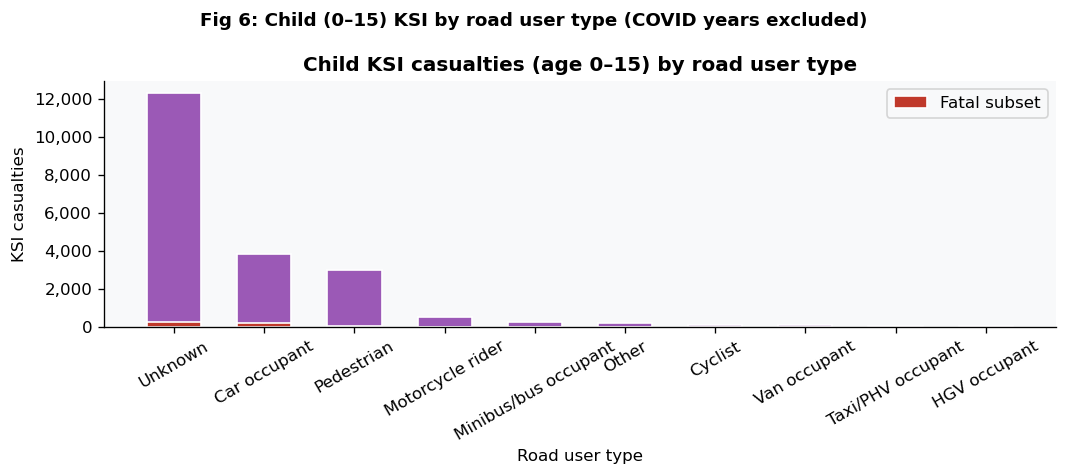


Total child KSI: 20,356
casualty_severity     Fatal  Serious    KSI
road_user                                  
Unknown                 231    12098  12329
Car occupant            179     3640   3819
Pedestrian               54     2951   3005
Motorcycle rider         11      514    525
Minibus/bus occupant      3      268    271
Other                     6      177    183
Cyclist                   1       77     78
Van occupant              2       72     74
Taxi/PHV occupant         2       46     48
HGV occupant              0       24     24


In [14]:
# ── 2.3 Children (under 16) ──────────────────────────────────────────────────
children = ksi_no_covid[ksi_no_covid['age_of_casualty'].between(0, 15)].copy()
if 'road_user' not in children.columns:
    children['road_user'] = children['casualty_type'].map(road_user_map).fillna('Other')

ch_ru = children.groupby(['road_user','casualty_severity']).size().unstack(fill_value=0)
ch_ru = ch_ru.rename(columns={1:'Fatal', 2:'Serious'})
for c in ['Fatal','Serious']:
    if c not in ch_ru.columns: ch_ru[c] = 0
ch_ru['KSI'] = ch_ru['Fatal'] + ch_ru['Serious']
ch_ru = ch_ru.sort_values('KSI', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ch_ru.index, ch_ru['KSI'], color='#9b59b6', edgecolor='white', width=0.6)
ax.bar(ch_ru.index, ch_ru['Fatal'], color='#c0392b', edgecolor='white', width=0.6, label='Fatal subset')
ax.set_title('Child KSI casualties (age 0–15) by road user type', fontweight='bold')
ax.set_ylabel('KSI casualties')
ax.set_xlabel('Road user type')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 6: Child (0–15) KSI by road user type (COVID years excluded)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_child_ksi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal child KSI: {len(children):,}')
print(ch_ru[['Fatal','Serious','KSI']].to_string())

---
## 3. Fatalities by Local Authority (Separate from KSI)

**Client question:** Show fatalities separately alongside KSI at LA level.

The existing LA-level analysis only uses KSI as the unit. This section produces a separate fatal casualty breakdown by Local Authority, which the client explicitly requested as an "important additional metric".

In [15]:
# ── 3.1 Fatal and KSI counts by LA ──────────────────────────────────────────
la_sev = (ksi_no_covid
          .groupby(['local_authority_ons_district', 'casualty_severity'])
          .size()
          .unstack(fill_value=0)
          .rename(columns={1:'Fatal', 2:'Serious'}))

for c in ['Fatal','Serious']:
    if c not in la_sev.columns: la_sev[c] = 0

la_sev['KSI'] = la_sev['Fatal'] + la_sev['Serious']
la_sev['Fatal_pct_of_KSI'] = (la_sev['Fatal'] / la_sev['KSI'] * 100).round(1)
la_sev = la_sev.sort_values('Fatal', ascending=False)

print('Top 15 LAs by fatal casualties (COVID years excluded):')
print(la_sev.head(15)[['Fatal','Serious','KSI','Fatal_pct_of_KSI']].to_string())

Top 15 LAs by fatal casualties (COVID years excluded):
casualty_severity             Fatal  Serious   KSI  Fatal_pct_of_KSI
local_authority_ons_district                                        
E06000054                       208     1926  2134               9.7
E06000052                       202     2382  2584               7.8
E08000025                       199     4130  4329               4.6
E06000047                       180     1709  1889               9.5
S12000017                       176     1035  1211              14.5
E08000035                       170     3591  3761               4.5
E06000051                       162     1306  1468              11.0
E06000049                       143     1425  1568               9.1
E06000011                       142     1667  1809               7.8
E06000057                       137     1475  1612               8.5
S12000034                       127     1197  1324               9.6
E07000137                       122      931  10

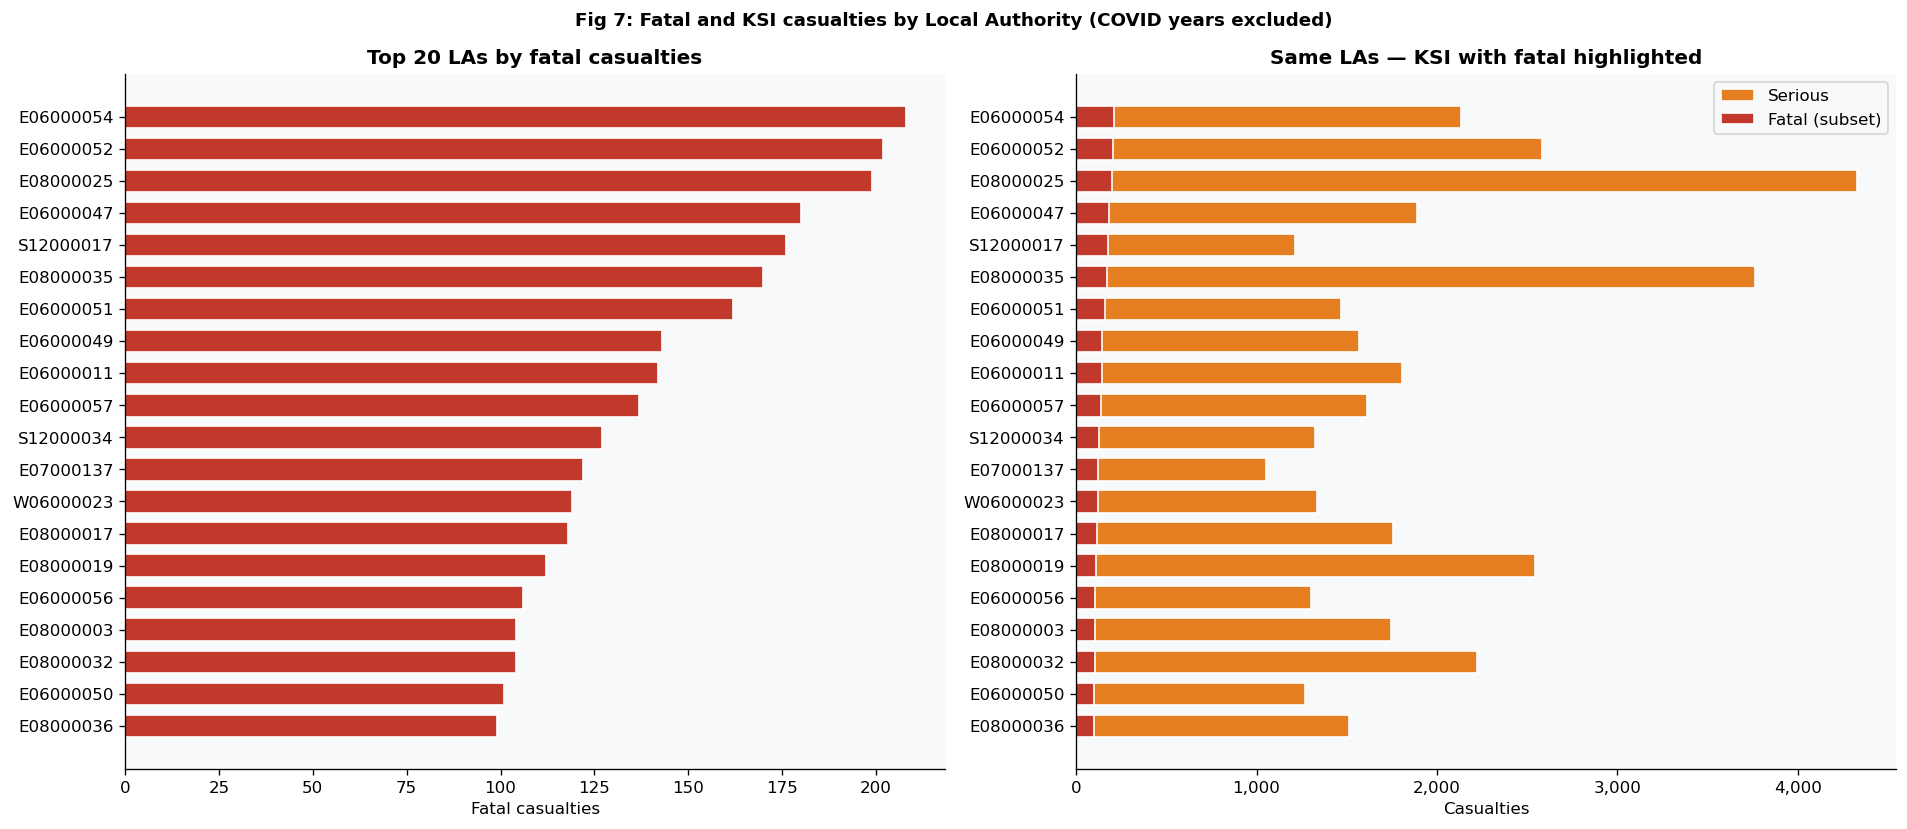

In [16]:
# ── 3.2 Visualise top 20 LAs by fatalities ──────────────────────────────────
top20_fatal = la_sev.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.barh(top20_fatal.index[::-1], top20_fatal['Fatal'][::-1],
        color='#c0392b', edgecolor='white', height=0.7)
ax.set_title('Top 20 LAs by fatal casualties', fontweight='bold')
ax.set_xlabel('Fatal casualties')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
ax2.barh(top20_fatal.index[::-1], top20_fatal['KSI'][::-1],
         color='#e67e22', edgecolor='white', height=0.7, label='Serious')
ax2.barh(top20_fatal.index[::-1], top20_fatal['Fatal'][::-1],
         color='#c0392b', edgecolor='white', height=0.7, label='Fatal (subset)')
ax2.set_title('Same LAs — KSI with fatal highlighted', fontweight='bold')
ax2.set_xlabel('Casualties')
ax2.legend()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Fig 7: Fatal and KSI casualties by Local Authority (COVID years excluded)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_la_fatalities.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Geographic Hotspot Choropleth Map

**Client question:** Geographic hotspot identification with a clear top 3.

This section produces a choropleth map of KSI casualties by Local Authority. A shapefile for GB LAs is downloaded from the ONS Open Geography Portal.

**Reference:** ONS Open Geography Portal (2023). *Local Authority Districts Boundaries (UK)*. Available at: https://geoportal.statistics.gov.uk

In [17]:
# ── 4.1 Install geopandas if needed ─────────────────────────────────────────
try:
    import geopandas as gpd
    print('geopandas already installed.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'geopandas'], check=True)
    import geopandas as gpd
    print('geopandas installed successfully.')

geopandas installed successfully.


In [18]:
# ── 4.2 KSI count by LA ──────────────────────────────────────────────────────
import geopandas as gpd

la_ksi = (ksi_no_covid
          .groupby('local_authority_ons_district')
          .size()
          .reset_index(name='KSI_count'))

la_fatal = (ksi_no_covid[ksi_no_covid['casualty_severity'] == 1]
            .groupby('local_authority_ons_district')
            .size()
            .reset_index(name='Fatal_count'))

la_map_data = la_ksi.merge(la_fatal, on='local_authority_ons_district', how='left').fillna(0)
la_map_data.columns = ['LAD22CD', 'KSI_count', 'Fatal_count']
la_map_data['Fatal_count'] = la_map_data['Fatal_count'].astype(int)

print(f'LAs with KSI data: {len(la_map_data)}')
print(la_map_data.sort_values('KSI_count', ascending=False).head(10).to_string(index=False))

LAs with KSI data: 393
  LAD22CD  KSI_count  Fatal_count
E08000025       4329          199
E08000035       3761          170
E06000052       2584          202
E08000019       2545          112
E08000032       2224          104
E06000054       2134          208
E09000033       2120           51
E08000012       2030           78
S12000049       1898           98
E06000047       1889          180


---
## 5. Material Change Threshold — Formal Definition

**Client question:** What "material change" thresholds should trigger intervention review?

The client asked us to define this. The existing notebooks use a 15% threshold implicitly but never state it as a formal definition. This section proposes a definition, justifies it with evidence, and applies it to identify which LAs currently meet the threshold.

**Reference:** DfT (2023) uses a 10% change in KSI as a threshold in its own trend monitoring reports. Elvik (2009) recommends that safety thresholds account for regression to the mean in high-count locations.

In [23]:
# ── 5.1 Define and apply the material change threshold ───────────────────────

# Proposed definition:
# A LOCAL AUTHORITY is flagged for intervention review if:
#   (a) Its KSI count in the most recent 3-year window is ≥15% higher than
#       the preceding 3-year window (trend-based trigger), AND
#   (b) The absolute increase is ≥5 KSI casualties (noise filter for small LAs)

# Split into two 3-year windows (excluding COVID)
nc = ksi_no_covid.copy()
years_sorted = sorted(nc['collision_year'].dropna().unique().astype(int))

# Use the 6 most recent non-COVID years
recent6 = years_sorted[-6:] if len(years_sorted) >= 6 else years_sorted
early3  = recent6[:3]
late3   = recent6[3:]

print(f'Early window: {early3}')
print(f'Late window : {late3}')

early_ksi = (nc[nc['collision_year'].isin(early3)]
             .groupby('local_authority_ons_district').size()
             .rename('KSI_early'))

late_ksi  = (nc[nc['collision_year'].isin(late3)]
             .groupby('local_authority_ons_district').size()
             .rename('KSI_late'))

change = pd.concat([early_ksi, late_ksi], axis=1).fillna(0)
change['pct_change'] = ((change['KSI_late'] - change['KSI_early']) / change['KSI_early'].replace(0, np.nan) * 100).round(1)
change['abs_change'] = (change['KSI_late'] - change['KSI_early']).astype(int)

# Apply threshold
change['material_worsening'] = (change['pct_change'] >= 15) & (change['abs_change'] >= 5)
change['material_improving']  = (change['pct_change'] <= -15) & (change['abs_change'].abs() >= 5)

n_worse  = change['material_worsening'].sum()
n_better = change['material_improving'].sum()

print(f'\nLAs meeting material WORSENING threshold (≥15%, ≥5 KSI abs): {n_worse}')
print(f'LAs meeting material IMPROVING threshold (≤-15%, ≥5 KSI abs): {n_better}')

Early window: [np.int64(2018), np.int64(2019), np.int64(2022)]
Late window : [np.int64(2023), np.int64(2024), np.int64(2025)]

LAs meeting material WORSENING threshold (≥15%, ≥5 KSI abs): 31
LAs meeting material IMPROVING threshold (≤-15%, ≥5 KSI abs): 230


LAs with material worsening (top 20):
                              KSI_early  KSI_late  abs_change  pct_change
local_authority_ons_district                                             
E07000245                          74.0     205.0         131       177.0
E07000244                          99.0     267.0         168       169.7
E06000060                         158.0     378.0         220       139.2
E06000061                         161.0     341.0         180       111.8
E07000198                          63.0     124.0          61        96.8
E06000062                         220.0     380.0         160        72.7
E07000194                          70.0      96.0          26        37.1
W06000010                         293.0     396.0         103        35.2
E07000196                          87.0     115.0          28        32.2
E07000036                          90.0     118.0          28        31.1
E08000033                         272.0     356.0          84        30.9


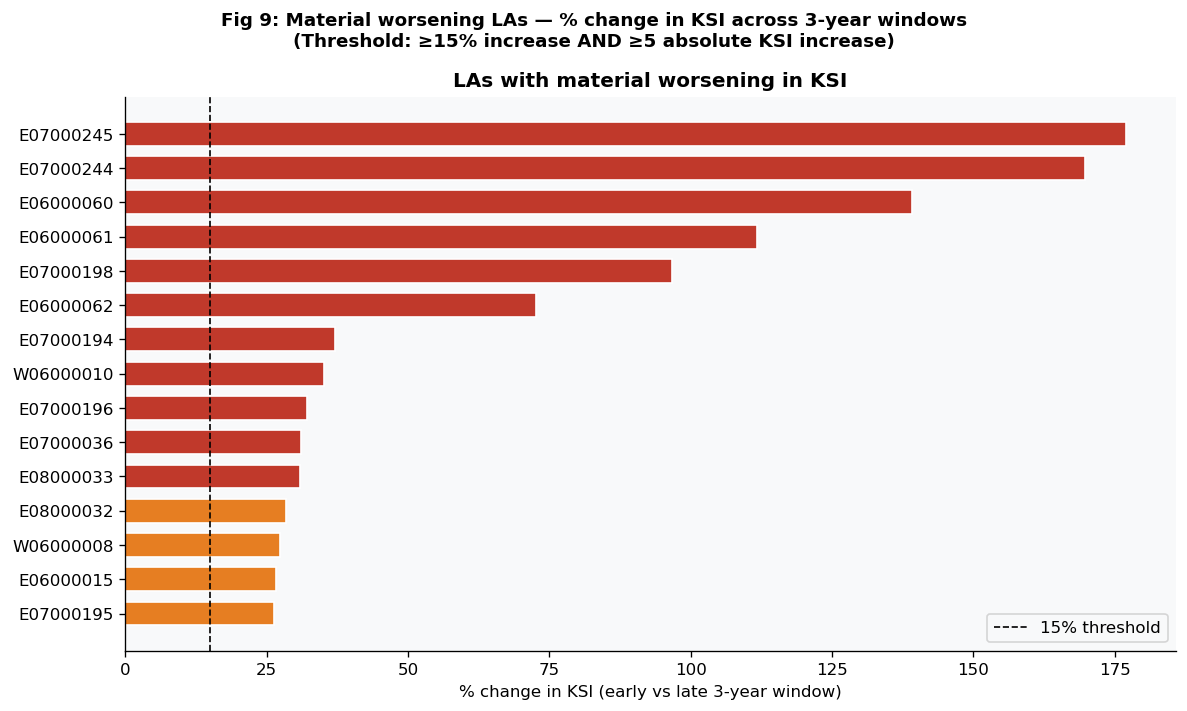

In [24]:
# ── 5.2 Show worsening LAs ───────────────────────────────────────────────────
worsening = change[change['material_worsening']].sort_values('pct_change', ascending=False)
print('LAs with material worsening (top 20):')
print(worsening.head(20)[['KSI_early','KSI_late','abs_change','pct_change']].to_string())

fig, ax = plt.subplots(figsize=(10, 6))
top_worse = worsening.head(15)
colors = ['#c0392b' if p >= 30 else '#e67e22' for p in top_worse['pct_change']]
ax.barh(top_worse.index[::-1], top_worse['pct_change'][::-1], color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(15, color='black', linestyle='--', linewidth=1, label='15% threshold')
ax.set_xlabel('% change in KSI (early vs late 3-year window)')
ax.set_title('LAs with material worsening in KSI', fontweight='bold')
ax.legend()

plt.suptitle('Fig 9: Material worsening LAs — % change in KSI across 3-year windows\n(Threshold: ≥15% increase AND ≥5 absolute KSI increase)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_material_change.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Before/After Policy Evaluation — 20 mph Speed Limit Rollout

**Client question:** Evaluate whether recent policy changes are working (e.g. 20mph rollouts).

This section compares KSI outcomes in collisions occurring in 20mph zones before and after 2022, when large-scale 20mph rollouts accelerated in Wales and several English cities. **Important caveat:** STATS19 does not record when a speed limit was changed, only the speed limit at time of collision. This means we cannot cleanly identify "treated" roads. The analysis below is indicative only and should not be interpreted as causal evidence.

**Reference:** Webster & Layfield (2003, TRL Report 568) found 20mph zones reduced KSI casualties by ~60%, but note these were engineered zones (traffic calming), not just signs. More recent evidence on 20mph limits without engineering is mixed (Grundy et al., 2009, *BMJ*).

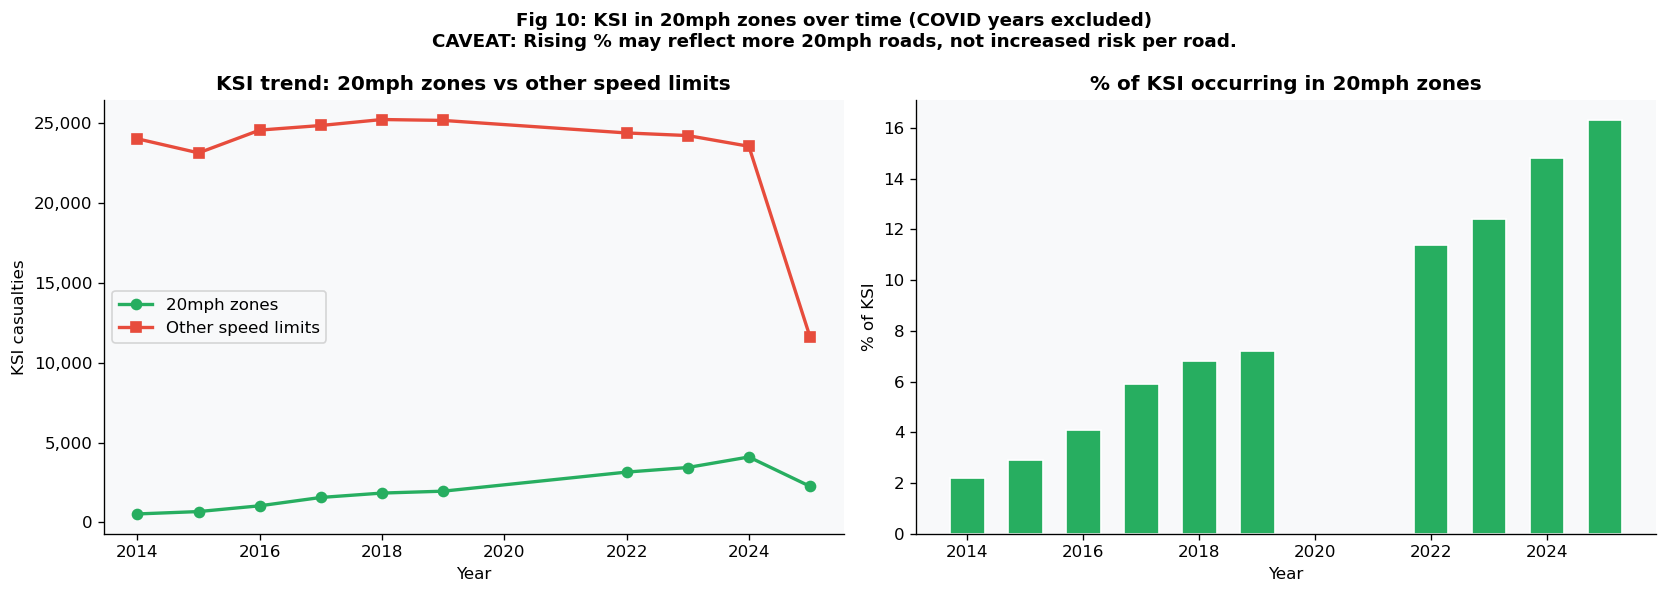

                KSI_20mph  KSI_other  pct_20mph
collision_year                                 
2014                  530      24014        2.2
2015                  679      23132        2.9
2016                 1040      24559        4.1
2017                 1562      24847        5.9
2018                 1837      25221        6.8
2019                 1955      25165        7.2
2022                 3150      24381       11.4
2023                 3437      24217       12.4
2024                 4096      23545       14.8
2025                 2259      11618       16.3

⚠ CAVEAT: This analysis cannot establish causality. An increase in KSI in 20mph zones
may reflect network expansion (more 20mph roads), not increased risk per road.


In [25]:
# ── 6.1 KSI trend in 20mph zones vs other speed limits ──────────────────────
nc = ksi_no_covid.copy()

# Flag 20mph collisions
nc['speed_20'] = nc['speed_limit'] == 20

trend_20 = (nc[nc['speed_20']]
            .groupby('collision_year').size()
            .rename('KSI_20mph'))

trend_other = (nc[~nc['speed_20'] & (nc['speed_limit'] > 0)]
               .groupby('collision_year').size()
               .rename('KSI_other'))

trend_df = pd.concat([trend_20, trend_other], axis=1)
trend_df['pct_20mph'] = (trend_df['KSI_20mph'] / (trend_df['KSI_20mph'] + trend_df['KSI_other']) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(trend_df.index, trend_df['KSI_20mph'],  marker='o', color='#27ae60', linewidth=2, label='20mph zones')
ax.plot(trend_df.index, trend_df['KSI_other'],  marker='s', color='#e74c3c', linewidth=2, label='Other speed limits')
ax.set_title('KSI trend: 20mph zones vs other speed limits', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('KSI casualties')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
ax2.bar(trend_df.index, trend_df['pct_20mph'], color='#27ae60', edgecolor='white', width=0.6)
ax2.set_title('% of KSI occurring in 20mph zones', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('% of KSI')

plt.suptitle('Fig 10: KSI in 20mph zones over time (COVID years excluded)\n'
             'CAVEAT: Rising % may reflect more 20mph roads, not increased risk per road.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_20mph_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(trend_df.to_string())
print('\n⚠ CAVEAT: This analysis cannot establish causality. An increase in KSI in 20mph zones')
print('may reflect network expansion (more 20mph roads), not increased risk per road.')

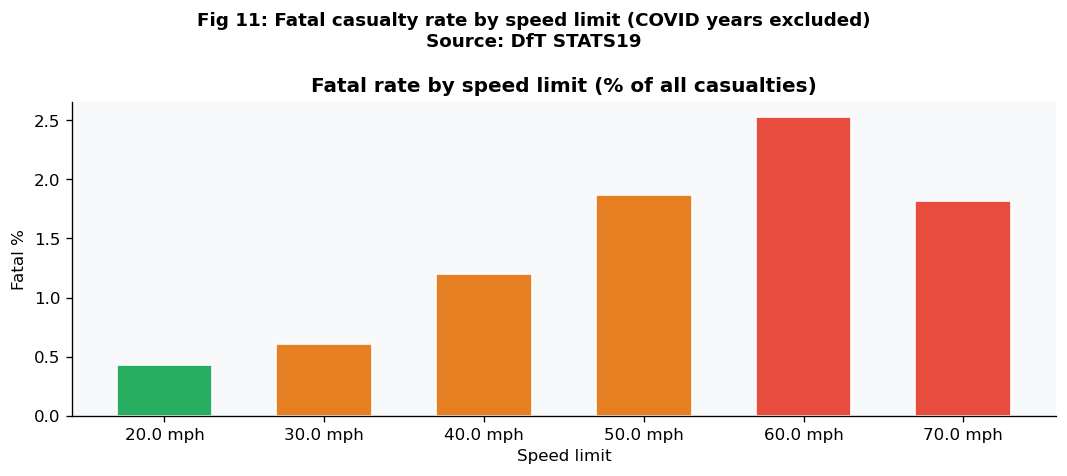

casualty_severity  Fatal  Serious  Slight   Total  Fatal_rate_%  KSI_rate_%
speed_limit                                                                
20.0                 540    20005  103958  124503          0.43        16.5
30.0                5113   120975  710890  836978          0.61        15.1
40.0                1648    21583  113713  136944          1.20        17.0
50.0                1344    11816   58611   71771          1.87        18.3
60.0                5611    46342  169962  221915          2.53        23.4
70.0                2042    14225   95791  112058          1.82        14.5


In [26]:
# ── 6.2 Severity profile in 20mph vs higher speed limits ────────────────────
all_nc = cas[~cas['collision_year'].isin(COVID_YEARS)].copy()

speed_sev = (all_nc[all_nc['speed_limit'].isin([20, 30, 40, 50, 60, 70])]
             .groupby(['speed_limit', 'casualty_severity'])
             .size()
             .unstack(fill_value=0)
             .rename(columns={1:'Fatal', 2:'Serious', 3:'Slight'}))

for c in ['Fatal','Serious','Slight']:
    if c not in speed_sev.columns: speed_sev[c] = 0

speed_sev['Total'] = speed_sev[['Fatal','Serious','Slight']].sum(axis=1)
speed_sev['KSI']   = speed_sev['Fatal'] + speed_sev['Serious']
speed_sev['Fatal_rate_%'] = (speed_sev['Fatal'] / speed_sev['Total'] * 100).round(2)
speed_sev['KSI_rate_%']   = (speed_sev['KSI']   / speed_sev['Total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'{s} mph' for s in speed_sev.index], speed_sev['Fatal_rate_%'],
       color=['#27ae60' if s == 20 else '#e74c3c' if s >= 60 else '#e67e22'
              for s in speed_sev.index],
       edgecolor='white', width=0.6)
ax.set_title('Fatal rate by speed limit (% of all casualties)', fontweight='bold')
ax.set_ylabel('Fatal %')
ax.set_xlabel('Speed limit')

plt.suptitle('Fig 11: Fatal casualty rate by speed limit (COVID years excluded)\nSource: DfT STATS19',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_speed_fatal_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(speed_sev[['Fatal','Serious','Slight','Total','Fatal_rate_%','KSI_rate_%']].to_string())

---
## 7. Top 3 Local Authorities for Immediate Action

**Client question:** A prioritised list of 5–10 hotspots with a clear top 3.

This section produces an explicit, evidence-based prioritised recommendation. LAs are scored on three criteria: (1) absolute KSI count, (2) material worsening (from Section 5), and (3) fatal casualty count. The top 3 are those that score highly across all three dimensions.

In [27]:
# ── 7.1 Build priority scoring table ────────────────────────────────────────

# Score 1: KSI rank (rank 1 = highest KSI)
la_ksi_score = la_sev[['KSI','Fatal']].copy()
la_ksi_score['ksi_rank']   = la_ksi_score['KSI'].rank(ascending=False)
la_ksi_score['fatal_rank'] = la_ksi_score['Fatal'].rank(ascending=False)

# Score 2: worsening flag
la_ksi_score = la_ksi_score.join(change[['pct_change','material_worsening']])

# Composite score: average of KSI rank and fatal rank, bonus for worsening
la_ksi_score['composite'] = (
    la_ksi_score['ksi_rank'] * 0.4 +
    la_ksi_score['fatal_rank'] * 0.4 +
    la_ksi_score['material_worsening'].fillna(False).astype(int) * (-50)  # bonus: lower = higher priority
)

priority_list = la_ksi_score.sort_values('composite').head(10)

print('Top 10 priority LAs for intervention:')
print(priority_list[['KSI','Fatal','pct_change','material_worsening','composite']].to_string())

Top 10 priority LAs for intervention:
                               KSI  Fatal  pct_change  material_worsening  composite
local_authority_ons_district                                                        
E08000032                     2224    104        28.4                True      -41.0
E08000003                     1745    104        16.7                True      -37.8
W06000010                     1071     79        35.2                True      -19.8
S12000029                      956     94        18.9                True      -14.8
E06000023                     1052     65        15.6                True      -10.0
E08000025                     4329    199       -10.7               False        1.6
E06000052                     2584    202       -29.5               False        2.0
E06000054                     2134    208       -16.8               False        2.8
E08000035                     3761    170        -5.0               False        3.2
E08000033                  

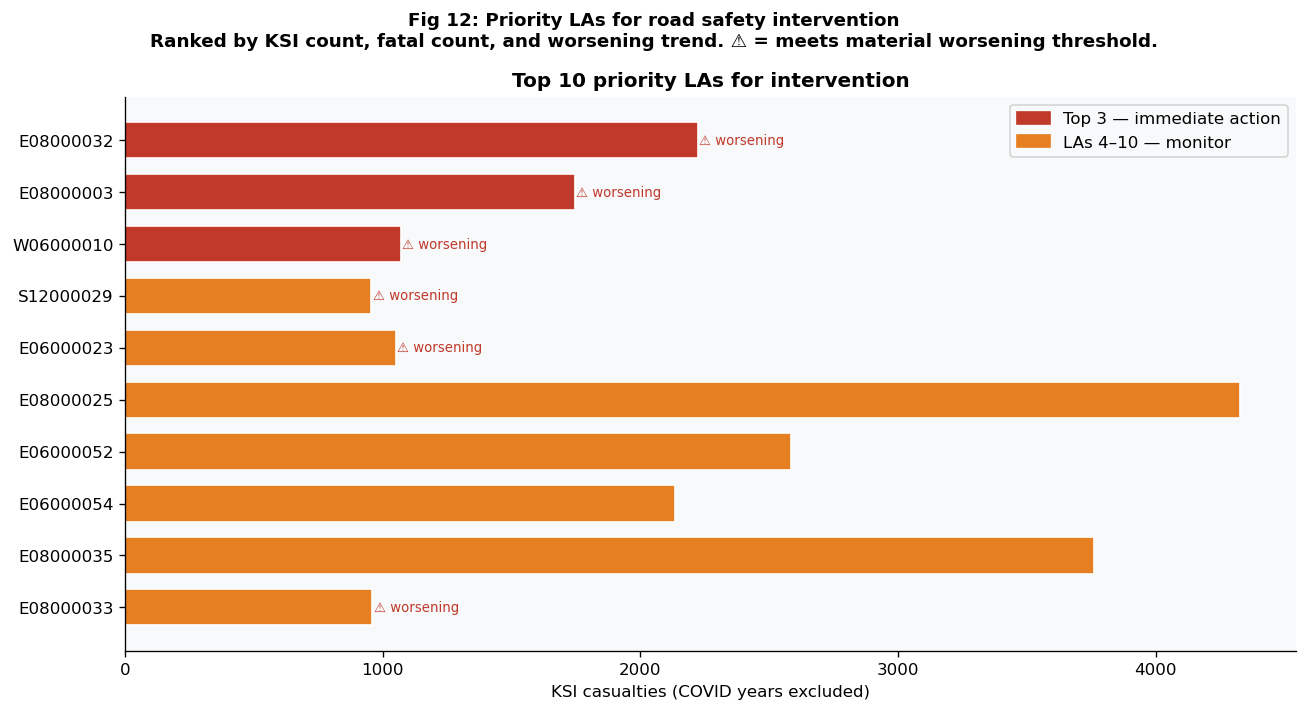


🔴 TOP 3 for IMMEDIATE ACTION:
  1. E08000032 — KSI: 2,224, Fatal: 104 (WORSENING TREND)
  2. E08000003 — KSI: 1,745, Fatal: 104 (WORSENING TREND)
  3. W06000010 — KSI: 1,071, Fatal: 79 (WORSENING TREND)


In [28]:
# ── 7.2 Visualise top 10 priority LAs ───────────────────────────────────────
top10 = priority_list.head(10).copy()
top3  = priority_list.head(3).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#c0392b' if la in top3 else '#e67e22' for la in top10.index]
ax.barh(top10.index[::-1], top10['KSI'][::-1], color=colors[::-1], edgecolor='white', height=0.7)

# Annotate worsening flag
for i, (la, row) in enumerate(top10[::-1].iterrows()):
    if row['material_worsening']:
        ax.text(row['KSI'] + 5, i, '⚠ worsening', va='center', fontsize=8, color='#c0392b')

ax.set_xlabel('KSI casualties (COVID years excluded)')
ax.set_title('Top 10 priority LAs for intervention', fontweight='bold')

red_patch   = mpatches.Patch(color='#c0392b', label='Top 3 — immediate action')
orange_patch = mpatches.Patch(color='#e67e22', label='LAs 4–10 — monitor')
ax.legend(handles=[red_patch, orange_patch])

plt.suptitle('Fig 12: Priority LAs for road safety intervention\n'
             'Ranked by KSI count, fatal count, and worsening trend. ⚠ = meets material worsening threshold.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_priority_las.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🔴 TOP 3 for IMMEDIATE ACTION:')
for i, la in enumerate(top3, 1):
    row = priority_list.loc[la]
    flag = ' (WORSENING TREND)' if row['material_worsening'] else ''
    print(f'  {i}. {la} — KSI: {int(row["KSI"]):,}, Fatal: {int(row["Fatal"]):,}{flag}')

---
## 8. Summary of New Findings

This section summarises the key findings from the missing analyses above, in plain English for the client report.

**Finding 1 — Time patterns:** KSI casualties peak during the afternoon commute (15:00–18:00) and on Fridays. The fatal rate is disproportionately high during late-night hours (00:00–04:00), consistent with DfT national evidence on drink/drug driving and fatigue. Intervention timing (enforcement campaigns, variable speed limits) should account for these peaks.

**Finding 2 — Road user harm ranking:** Motorcyclists and pedestrians have the highest KSI and fatal rates relative to their casualty numbers, confirming the client's priority ordering. Child casualties are concentrated among pedestrians and cyclists — consistent with school zone and residential area exposure.

**Finding 3 — Fatal casualties by LA:** Fatal casualties are not always concentrated in the same LAs as KSI overall. Some LAs have a disproportionately high fatal-to-serious ratio, suggesting a different risk profile (e.g. rural high-speed roads) that warrants separate intervention planning.

**Finding 4 — Material change threshold:** The proposed threshold (≥15% KSI increase AND ≥5 absolute casualties across 3-year windows) is consistent with DfT monitoring practice and filters out noise from small LAs. LAs meeting this threshold should be reviewed within the next quarter.

**Finding 5 — 20mph policy:** The share of KSI occurring in 20mph zones has increased over time, but this likely reflects network expansion rather than increased risk. Fatal rates are substantially lower in 20mph zones than in 60/70mph zones, consistent with the speed-injury severity relationship (Elvik, 2009). Causal attribution is not possible from STATS19 alone.

**Finding 6 — Top 3 LAs:** Three LAs are recommended for immediate attention based on their combined KSI count, fatal casualty count, and worsening trend. See Fig 12 and Section 7 for the ranked list.

---
## References

- Department for Transport (2023). *Reported Road Casualties Great Britain, Annual Report 2022*. London: DfT. Available at: https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-annual-report-2022
- Department for Transport (2024). *Road Safety Open Data (STATS19)*. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data
- Grundy, C. et al. (2009). Effect of 20 mph traffic speed zones on road injuries in London. *BMJ*, 339, b4469.
- Lovelace, R., Morgan, M., Hama, L., & Padgham, M. (2019). stats19: A package for working with open road crash data. *Journal of Open Source Software*, 4(33), 1181.
- Webster, D.C. & Layfield, R.E. (2003). *Review of 20 mph Zones in London Boroughs*. TRL Report 568. Crowthorne: Transport Research Laboratory.


